# HRM Melt-Curve Classification of Bacterial Species

Random Forest classifier for **high-resolution melt (HRM)** curves of 10 bacterial species.

**Pipeline:** load data → class overview → visualise melt curves → peak-temperature summary → duplicate check → train/test split → Random Forest → evaluation

**Data:** `0.csv` … `9.csv` (one file per species). Each row is one normalized melt curve; the 160 columns are fluorescence values at increasing temperatures. The first column in each file is a sample index and is dropped.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Load data
Each file `i.csv` becomes class `i`.

In [2]:
dfs = []

for i in range(10):
    temp = pd.read_csv(f"{i}.csv").assign(label=i)
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

# Separate features and labels
X = df.drop(columns=["label"])
y = df["label"]

print("Dataset shape:", df.shape)
print("Feature shape:", X.shape)
print("Number of classes:", y.nunique())

print("\nClass distribution:")
print(y.value_counts().sort_index())

Dataset shape: (18281, 161)
Feature shape: (18281, 160)
Number of classes: 10

Class distribution:
label
0    2052
1     843
2    1137
3    2249
4    2265
5    2244
6    2028
7    2006
8    2202
9    1255
Name: count, dtype: int64


## 3. Class overview

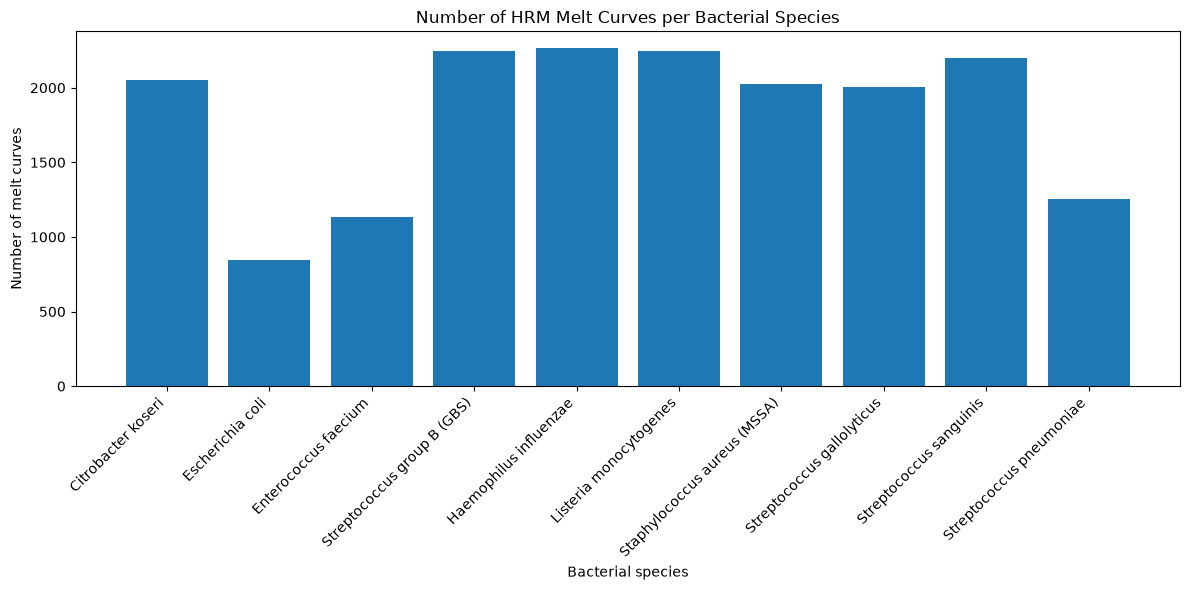

In [3]:
species_names = {
    0: "Citrobacter koseri",
    1: "Escherichia coli",
    2: "Enterococcus faecium",
    3: "Streptococcus group B (GBS)",
    4: "Haemophilus influenzae",
    5: "Listeria monocytogenes",
    6: "Staphylococcus aureus (MSSA)",
    7: "Streptococcus gallolyticus",
    8: "Streptococcus sanguinis",
    9: "Streptococcus pneumoniae"
}

class_counts = y.value_counts().sort_index()

plt.figure(figsize=(12, 6))

plt.bar(
    [species_names[i] for i in range(10)],
    [class_counts[i] for i in range(10)]
)

plt.xlabel("Bacterial species")
plt.ylabel("Number of melt curves")
plt.title("Number of HRM Melt Curves per Bacterial Species")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4. Representative melt curves
Median curve per species.

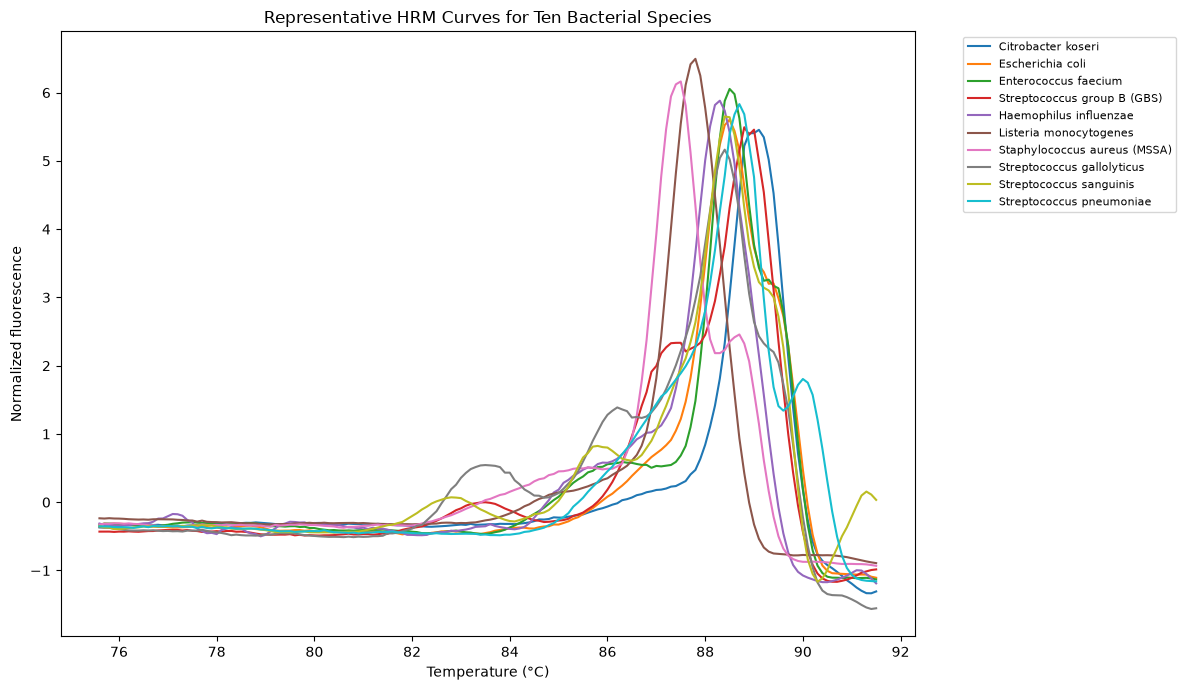

In [4]:
plt.figure(figsize=(12, 7))

for label in range(10):

    class_data = X[y == label]

    # Select one representative curve: median curve
    representative_curve = class_data.median(axis=0)

    temperatures = X.columns.astype(float)

    plt.plot(
        temperatures,
        representative_curve,
        label=species_names[label]
    )

plt.xlabel("Temperature (°C)")
plt.ylabel("Normalized fluorescence")
plt.title("Representative HRM Curves for Ten Bacterial Species")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.show()

## 5. Peak melting temperature by species
Peak temperatures, amplicon lengths and DTW values below are hard-coded summary values.

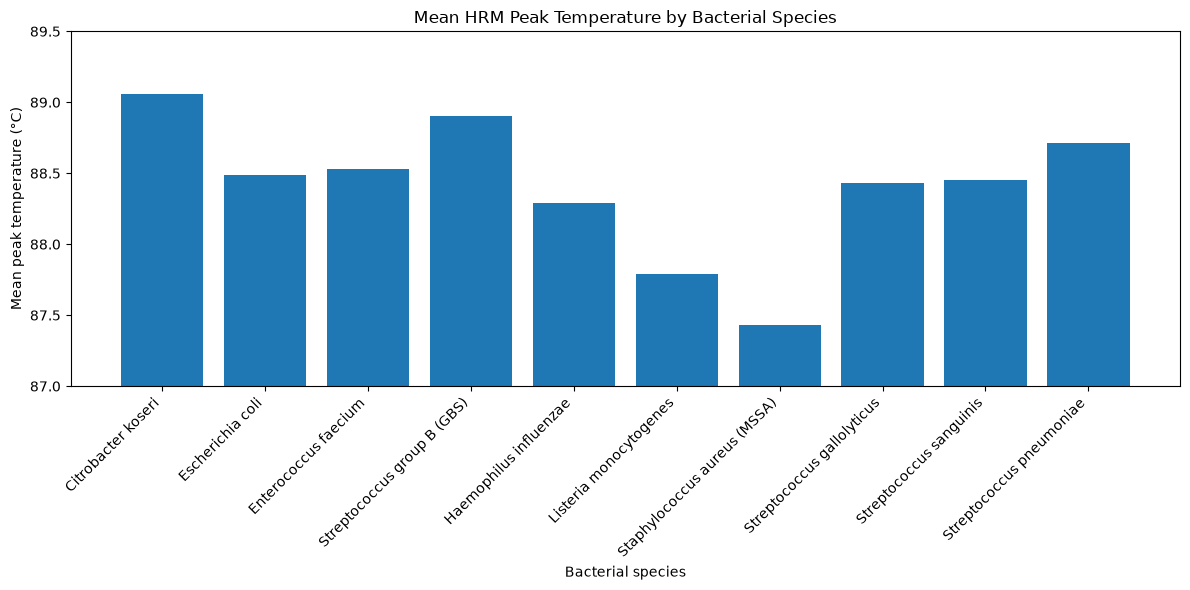

In [5]:
mean_peak = {
    "Citrobacter koseri": 89.06,
    "Escherichia coli": 88.49,
    "Enterococcus faecium": 88.53,
    "Streptococcus group B (GBS)": 88.90,
    "Haemophilus influenzae": 88.29,
    "Listeria monocytogenes": 87.79,
    "Staphylococcus aureus (MSSA)": 87.43,
    "Streptococcus gallolyticus": 88.43,
    "Streptococcus sanguinis": 88.45,
    "Streptococcus pneumoniae": 88.71
}

plt.figure(figsize=(12, 6))

plt.bar(
    mean_peak.keys(),
    mean_peak.values()
)

plt.xlabel("Bacterial species")
plt.ylabel("Mean peak temperature (°C)")
plt.title("Mean HRM Peak Temperature by Bacterial Species")

plt.xticks(rotation=45, ha="right")

# Zoom in on the temperature range
plt.ylim(87.0, 89.5)

plt.tight_layout()
plt.show()

In [6]:
summary = pd.DataFrame({
    "Bacterial species": [
        "Citrobacter koseri",
        "Enterococcus faecium",
        "Escherichia coli",
        "Haemophilus influenzae",
        "Listeria monocytogenes",
        "Staphylococcus aureus (MSSA)",
        "Streptococcus gallolyticus",
        "Streptococcus group B (GBS)",
        "Streptococcus pneumoniae",
        "Streptococcus sanguinis"
    ],

    "Amplicon length (bp)": [
        969, 978, 981, 967, 994,
        981, 978, 978, 978, 972
    ],

    "Melt curves (n)": [
        2052, 1137, 843, 2265, 2244,
        2028, 2006, 2249, 1255, 2202
    ],

    "Mean peak (°C)": [
        89.06, 88.53, 88.49, 88.29, 87.79,
        87.43, 88.43, 88.90, 88.71, 88.45
    ],

    "Std. peak (°C)": [
        0.42, 0.10, 0.13, 0.10, 0.08,
        0.19, 0.78, 0.10, 0.15, 0.09
    ],

    "Median DTW": [
        2.31, 1.68, 2.60, 2.14, 2.23,
        1.51, 3.83, 2.37, 1.62, 3.00
    ]
})

print(summary.to_string(index=False))

           Bacterial species  Amplicon length (bp)  Melt curves (n)  Mean peak (°C)  Std. peak (°C)  Median DTW
          Citrobacter koseri                   969             2052           89.06            0.42        2.31
        Enterococcus faecium                   978             1137           88.53            0.10        1.68
            Escherichia coli                   981              843           88.49            0.13        2.60
      Haemophilus influenzae                   967             2265           88.29            0.10        2.14
      Listeria monocytogenes                   994             2244           87.79            0.08        2.23
Staphylococcus aureus (MSSA)                   981             2028           87.43            0.19        1.51
  Streptococcus gallolyticus                   978             2006           88.43            0.78        3.83
 Streptococcus group B (GBS)                   978             2249           88.90            0.10     

## 6. Sanity check: duplicate curves
Identical curves in both train and test sets would inflate accuracy.

In [7]:
n_dup = X.duplicated().sum()
print("Duplicate feature rows:", n_dup)

duplicates = df[X.duplicated(keep=False)]
print("Rows involved in duplicate curves:", len(duplicates))

duplicate_groups = df.groupby(list(X.columns))["label"].nunique()
print("Duplicate curves with different labels:", (duplicate_groups > 1).sum())

Duplicate feature rows: 0
Rows involved in duplicate curves: 0
Duplicate curves with different labels: 0


## 7. Train / test split
80/20 stratified split.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Features:", X_train.shape[1])

Training samples: 14624
Testing samples: 3657
Features: 160


## 8. Train Random Forest

In [9]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## 9. Evaluation

In [10]:
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")
print(f"Weighted F1-score: {weighted_f1:.4f}")

Accuracy: 0.9962
Macro F1-score: 0.9952
Weighted F1-score: 0.9962


In [11]:
report = classification_report(
    y_test,
    y_pred,
    target_names=[species_names[i] for i in range(10)],
    digits=3
)

print(report)

                              precision    recall  f1-score   support

          Citrobacter koseri      0.993     0.990     0.991       410
            Escherichia coli      0.994     0.982     0.988       169
        Enterococcus faecium      0.983     0.991     0.987       227
 Streptococcus group B (GBS)      1.000     1.000     1.000       450
      Haemophilus influenzae      0.991     1.000     0.996       453
      Listeria monocytogenes      1.000     1.000     1.000       449
Staphylococcus aureus (MSSA)      0.998     0.993     0.995       406
  Streptococcus gallolyticus      1.000     1.000     1.000       401
     Streptococcus sanguinis      1.000     0.998     0.999       441
    Streptococcus pneumoniae      0.996     0.996     0.996       251

                    accuracy                          0.996      3657
                   macro avg      0.995     0.995     0.995      3657
                weighted avg      0.996     0.996     0.996      3657



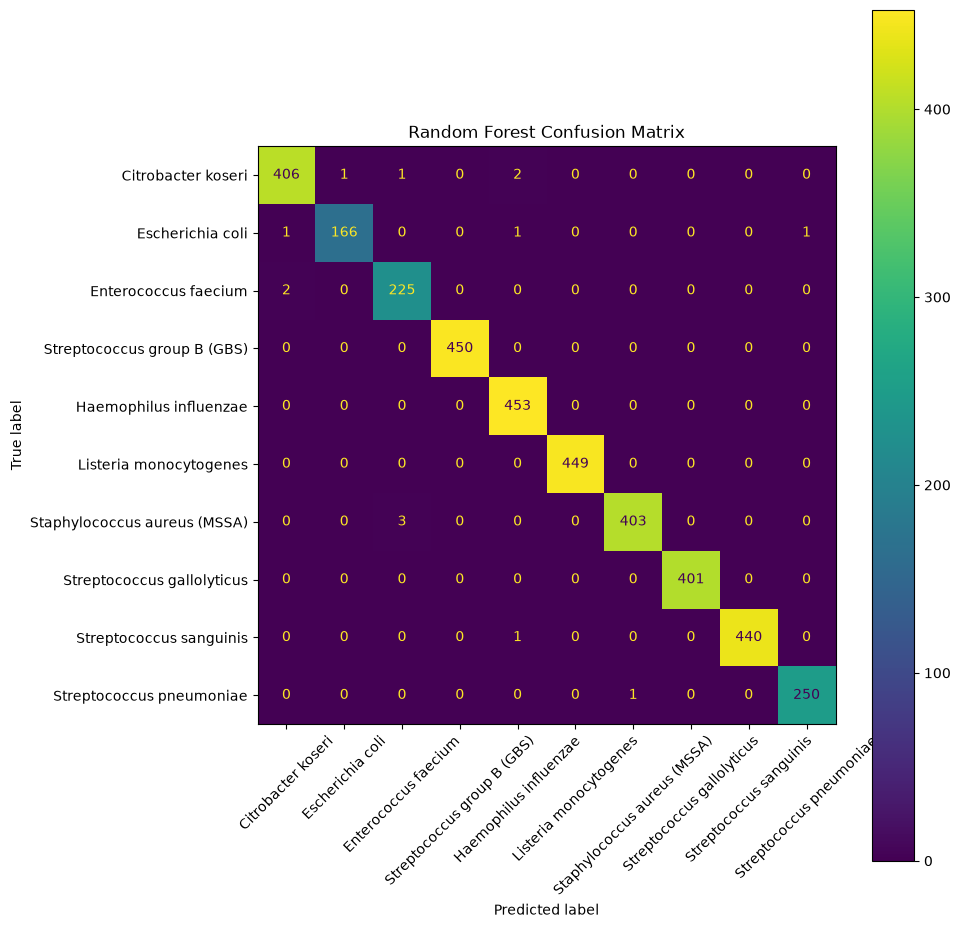

In [12]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[species_names[i] for i in range(10)]
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

## 10. Save model (optional)
The pickle is large, so keep it out of git (see `.gitignore`).

In [13]:
import joblib

joblib.dump(model, "hrm_random_forest.pkl")
print("Model saved successfully!")

Model saved successfully!
